# Volumetric Analysis for Particle Detection

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage
import scipy

from numpy.typing import NDArray
from scipy.ndimage import gaussian_filter1d, map_coordinates

import sys

sys.path.insert(0, str(Path.cwd().parent))

from metal import estimate_metal_threshold, extract_metal_mask, estimate_grayscale_range
from enhance import softmax_projection

from volume import load_volume, voxel_size_mm

plt.style.use("dark_background")


# Configuration & Utilities

In [2]:
data_dir = Path.cwd().parent / "Data"
vol = load_volume(data_dir / "M50L-06.raw")
z_top, z_bottom = 200, 4070
vol = vol[z_top:z_bottom]
vol_center_row = (vol.shape[1]) / 2
vol_center_col = (vol.shape[2]) / 2
pixel_size_mm = voxel_size_mm(data_dir / "M50L-06.raw")
print(f"Shape : {vol.shape}\nDtype : {vol.dtype}\nVoxel : {pixel_size_mm} mm")

Shape : (3870, 1425, 1425)
Dtype : uint8
Voxel : (0.01640435, 0.01640435, 0.01640435) mm


## Utils

In [3]:
def plot(img: np.ndarray, title: str = "", figsize: tuple = (12, 12)) -> None:
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


# Identify Landmark Grayscale Values - Air, Metal and Max
Any gray level below 'air' value is considered background air
Any gray level above the 'metal' value is considered hig-z metal
Any gray level above the estimated max grayscale value is assumed saturated

In [4]:
air_grayvalue, max_grayvalue = estimate_grayscale_range(vol, slice_step=200)
min_grayvalue = air_grayvalue
metal_threshold = estimate_metal_threshold(vol, air_grayvalue, slice_step=200)
print(f"Estimated Air Gray Value: {air_grayvalue}")
print(f"Estimated Metal Threshold: {metal_threshold}")
print(f"Estimated Max Gray Value: {max_grayvalue}")

Right Peak: 128, Other Peaks: [180], Prominences: [27888.15163607]
Estimated Air Gray Value: 93
Estimated Metal Threshold: 154
Estimated Max Gray Value: 219


# Set the slab location and thickness

In [5]:
# slice range 905-914
slice_loc = 910

slab_thickness = 60
z_range = slice_loc - slab_thickness // 2, slice_loc + slab_thickness // 2 + 1
slab = vol[z_range[0] : z_range[1], :, :]

# Extract the metal mask for the slab

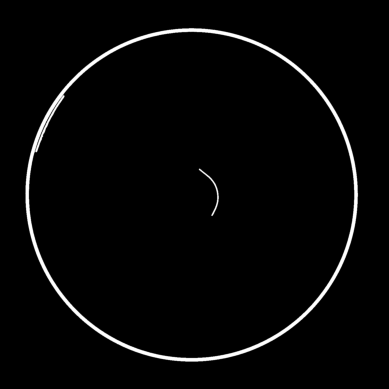

In [6]:
metal = extract_metal_mask(np.max(slab, axis=0), metal_threshold, min_area=200)
plt.imshow(metal, cmap="gray")
plt.axis("off")
plt.show()

## Compare average, softmax and max projections

In [7]:
softmax = softmax_projection(slab, beta=200, window=11)
zmax = np.max(slab, axis=0)
zavg = np.mean(slab, axis=0)

c_slice = slice(100, 400)
r_slice = slice(300, 600)

In [ ]:
plt.figure(figsize=(28, 28))

metal3D = slab > metal_threshold
clean = np.where(metal3D, air_grayvalue, slab).astype(np.uint8)
tmp = softmax_projection(clean, beta=10, window=5)
tmp[metal] = zavg[metal]


plt.subplot(1, 3, 1)
plt.imshow(tmp[r_slice, c_slice], cmap="gray")
# plt.imshow(softmax[r_slice, c_slice], cmap="gray")
plt.title("Softmax Projection")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(zavg[r_slice, c_slice], cmap="gray")
plt.title("Average Projection")
plt.axis("off")

plt.subplot(1, 3, 3)
tmp = zmax.copy()
tmp[metal] = zavg[metal]
plt.imshow(tmp[r_slice, c_slice], cmap="gray")
plt.title("Max Projection")
plt.axis("off")


In [ ]:
diff = zmax.astype(np.int16) - softmax.astype(np.int16)
print(f"Max Diff: {np.max(diff)}  Min Diff: {np.min(diff)}")
plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.imshow(diff[r_slice, c_slice], cmap="gray")


plt.subplot(1, 2, 2)
plt.hist(diff.flatten(), bins=100)
plt.title("Difference (Max - Softmax)")
plt.axis("off")


In [ ]:
base = np.median(slab, axis=0, keepdims=True).astype(np.int16)
delta = np.clip(slab.astype(np.int16) - base, 0, 255).astype(np.uint8)
enh = softmax_projection(delta, beta=10, window=5)
enh = delta.max(axis=0)

plt.figure(figsize=(28, 28))
plt.imshow(enh[r_slice, c_slice], cmap="gray")

# End

# New contrast enhancement function exploration

In [ ]:
enh[metal] = slab[slab.shape[0] // 2][metal]
low = np.percentile(slab, 50, axis=0)
low[metal] = slab[slab.shape[0] // 2][metal]


plt.subplot(1, 3, 2)
diff = enh - low
print(
    f"metal shape: {metal.shape}, metal dtype: {metal.dtype}, metal true count: {metal.sum()}"
)

# diff[metal>0] = 0
print(f"diff type: {diff.dtype}, diff min: {diff.min()}, diff max: {diff.max()}")
diff = cv2.GaussianBlur(diff, (3, 3), 0)
diff = slab.max(axis=0)
plt.imshow(diff[r_slice, c_slice], cmap="gray")
plt.axis("off")

avg = slab.mean(axis=0)
plt.subplot(1, 3, 3)
plt.imshow(avg[r_slice, c_slice], cmap="gray")
plt.axis("off")

plt.show()


## Max Projection

In [ ]:
max_slab = np.max(slab, axis=0)

# Analyze the slice at 890

In [ ]:
# del slice
slice_loc = 905

slab_thickness = 10
r_slice = slice(200 * 0, 650 * 10)
c_slice = slice(0, 450 * 10)
z_range = slice_loc - slab_thickness // 2, slice_loc + slab_thickness // 2 + 1
slab = vol[z_range[0] : z_range[1], r_slice, c_slice]

_mean = np.median(slab, axis=0)
_max = slab.max(axis=0)
_metal = extract_metal_mask(_max, metal_threshold, min_area=200)

# TESTING
low_threshold = metal_threshold - 20
seeds, _ = scipy.ndimage.label(_metal)
basin = _max > low_threshold
labels = skimage.segmentation.watershed(-_max.astype(np.uint16), seeds, mask=basin)
_metal = labels > 0
# END TESTING


img = _max.astype(np.int16) - _mean.astype(np.int16)
img[_metal] = 0  # Set metal regions to 0 to avoid extreme values skewing the contrast
img = img / 3.2
img = img * (img > 2)
# img = (img - img.min()) / max(img.max() - img.min(), 1e-6) * 255.0

idx = np.unravel_index(np.argmax(img), img.shape)
print(f"Max value at {idx} with gray value {img[idx]}")
print(
    f"Max value at particle location: _max: {_max[idx]}, _mean: {_mean[idx]}, _metal: {_metal[idx]}"
)

plt.figure(figsize=(12, 12))
plt.imshow(img.astype(np.uint8), cmap="gray")
plt.title(f"Slice {slice_loc}")
# plt.axis("off")
plt.show()

hist = cv2.calcHist(
    [img.astype(np.float32)], [0], None, [256], [img.min(), img.max()]
).squeeze()
hist, bin_edges = np.histogram(img, bins=256, range=(img.min(), 10))
hist[0] = 0

plt.figure(figsize=(12, 6))
plt.stairs(hist, bin_edges, color="blue")
plt.title("Histogram of Processed Image")
plt.xlabel("Gray Value")
plt.ylabel("Frequency")
plt.xlim(0, 255)
plt.grid()
plt.show()

print(img.min(), img.max())

# Estimate the center locations of the cell as a function of z

Note: Rows and cols are somewhat arbitrary in this analysis, they justs represent axix in the directions perpendicular to z.
**Findings:**
- The center location drifts down the cell - average of (-0.0032, 0.0047) drift per voxel
- The rows are more well-centered while the columns are slightly off-center

Conclusion:
- Tilt is minor, no need to adjust for lateral drift
- Central tab is a significant source of difference
  - Segment out the tab region
- Central anodes are a secondary source of difference
- The differences we see in adjacent slices establishes noise/recon patterns that need to be overcome by the particle size and contrast.

In [ ]:
centers = []
for z in range(z_top, z_bottom + 1):
    slice = vol[z]
    grad_x = cv2.Scharr(slice, cv2.CV_16S, 1, 0)
    grad_y = cv2.Scharr(slice, cv2.CV_16S, 0, 1)
    edges = cv2.Canny(grad_x, grad_y, 100, 200, L2gradient=True)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = sorted(contours, key=cv2.contourArea, reverse=True)[0]
    ellipse = cv2.fitEllipse(largest_contour)
    cc, cr = ellipse[0]
    centers.append((z, cr, cc))

centers_calculated = True
centers = np.array(centers)
print(centers.shape)

# Review the slice near 890

centers.shape

# Scratch

In [ ]:
# Create a rectangular mask
mask = np.zeros((vol.shape[1] // 2, vol.shape[2] // 2), dtype=np.uint8)
mask[100:600, 200:400] = 255
plt.figure(figsize=(12, 12))
h, w = mask.shape
M = cv2.getRotationMatrix2D(center=(w / 2, h / 2), angle=5, scale=1.0)
#plt.imshow(mask, cmap="gray")
mask = cv2.warpAffine(mask, M, (w, h))

smask = np.zeros_like(mask)
smask[:-1, :] = mask[1:, :]
bottom = mask.astype(np.bool_) &  ~smask.astype(np.bool_)

plt.imshow(bottom, cmap="gray")